# Fellegi-Sunter with Splink — **ground-truth (supervised) training**, binary match / non-match — v1

A probabilistic entity-resolution model built with **Splink 4** over the gold-labeled record
pairs. The task is **binary**: predict whether a pair is a *match* (`final_gold_label = True`) or
*non-match*. Ambiguous pairs are kept in training/scoring; evaluation reports both with and
without them.

**This notebook learns `m` supervised, directly from the gold labels** via
`estimate_m_from_pairwise_labels` on the train-split positives — the same procedure the production
matcher uses (`src/models/fs_matcher/`). `u` is estimated by random sampling and `λ` is seeded from
deterministic rules. Its sibling notebook, `fs_splink_em_v1.ipynb`, learns `m` unsupervised via
EM — same features, same splits, so the two are directly comparable (the supervised-vs-EM gap is
the value of the labels).

**Pipeline:** 1) setup · 2) ingest gold labels · 3) target · 4) record frame + candidate pairs ·
5) rich comparisons · 6) settings + λ-prior · 7) split · 8) **supervised training** · 9) score ·
10) evaluation.

> Standalone research/evaluation notebook — not wired into `src/pipeline.py`. Not executed at
> authoring time (Splink + the PHI data live on the VM); run top-to-bottom there.

## 1. Setup & configuration

In [2]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    precision_score, recall_score, f1_score,
)

import splink.comparison_library as cl
from splink import Linker, DuckDBAPI, SettingsCreator

pd.set_option('display.max_columns', 80)
RANDOM_STATE = 42
print('splink import OK')

splink import OK


## 2. Data ingestion
`dtype=str` on PATIDs preserves the leading-zeros invariant.

In [3]:
from pathlib import Path

def _find_service_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / 'data').is_dir() and (d / 'src').is_dir():
            return d
    raise FileNotFoundError("could not locate empi-service/ (no ancestor has data/ + src/)")

def _latest(base: Path, *globs: str) -> Path:
    # Newest file (lexicographic, so date-suffixed names sort correctly).
    hits = []
    for g in globs:
        hits += list(base.glob(g))
    if not hits:
        raise FileNotFoundError(f"no file matching {globs} under {base}")
    return sorted(hits)[-1]

SERVICE_ROOT = _find_service_root(Path.cwd())
DATA_DIR = SERVICE_ROOT / 'data'

# Auto-resolve the newest gold-label CSV and cleaned parquet; override by hand if needed.
GOLD_LABELS_PATH = _latest(DATA_DIR / 'gold_labels', '*gold*label*.csv', '*gold*.csv')
CLEANED_PATH = _latest(DATA_DIR / 'processed', '*cleaned*.parquet', '*.parquet')

print('service root :', SERVICE_ROOT)
print('gold labels  :', GOLD_LABELS_PATH, '->', GOLD_LABELS_PATH.exists())
print('cleaned data :', CLEANED_PATH, '->', CLEANED_PATH.exists())

service root : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service
gold labels  : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\data\gold_labels\final_gold_labels_v1_2026_07_05.csv -> True
cleaned data : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\data\processed\MDM_Population_cleaned_v6_2026_06_25.parquet -> True


In [4]:
gold = pd.read_csv(GOLD_LABELS_PATH, dtype={'PATID_A': str, 'PATID_B': str})

def _to_bool(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s
    return s.astype(str).str.strip().str.lower().map(
        {'true': True, '1': True, '1.0': True, 'false': False, '0': False, '0.0': False})

gold['final_gold_label'] = _to_bool(gold['final_gold_label']).fillna(False).astype(bool)
gold['ambiguous_pair'] = _to_bool(gold['ambiguous_pair']).fillna(False).astype(bool)

# Canonicalize the pair key so PATID_A < PATID_B (string order) — matches the
# ordering Splink emits for dedupe_only, so the join back is clean.
lo = np.minimum(gold['PATID_A'], gold['PATID_B'])
hi = np.maximum(gold['PATID_A'], gold['PATID_B'])
gold['PATID_A'], gold['PATID_B'] = lo, hi
gold = gold.drop_duplicates(subset=['PATID_A', 'PATID_B']).reset_index(drop=True)

print('gold labels shape :', gold.shape)
print('\nfinal_gold_label x ambiguous_pair (counts):')
print(pd.crosstab(gold['final_gold_label'], gold['ambiguous_pair']))

gold labels shape : (204805, 4)

final_gold_label x ambiguous_pair (counts):
ambiguous_pair     False  True 
final_gold_label               
False             142195     73
True               34560  27977


## 3. Binary target + 3-way group

Per the project decision, **ambiguous pairs are kept in training and scoring** — the
binary target is simply `final_gold_label` (1 = match, 0 = non-match) for *every* pair,
ambiguous or not.

We also carry a **3-way group label** used only for reporting: it partitions each pair into
`confident_match`, `confident_non_match`, or `ambiguous`. This drives (a) a second evaluation
that *excludes* ambiguous pairs, and (b) the histogram of predicted probabilities colored by group.

In [5]:
gold['is_match'] = gold['final_gold_label'].astype(int)

gold['pair_group'] = np.where(
    gold['ambiguous_pair'], 'ambiguous',
    np.where(gold['final_gold_label'], 'confident_match', 'confident_non_match'))

print('binary target (is_match):')
print(gold['is_match'].value_counts(dropna=False), '\n')
print('3-way group:')
print(gold['pair_group'].value_counts(dropna=False))
print(f"\nmatch prevalence: {gold['is_match'].mean():.3f}")

binary target (is_match):
is_match
0    142268
1     62537
Name: count, dtype: int64 

3-way group:
pair_group
confident_non_match    142195
confident_match         34560
ambiguous               28050
Name: count, dtype: int64

match prevalence: 0.305


## 4. Build the Splink record frame + candidate pairs (gold-labeled pairs only)

Splink scores **records**, not pre-joined pairs, so we assemble a record frame from the
union of PATIDs that appear in the gold labels, attach the cleaned attributes, and derive the
two helper columns the production matcher uses (`_dob_str`, `Phones_array`).

To restrict Splink to *exactly the gold-labeled pairs* we use the production trick: a
`candidate_pairs` table plus an `EXISTS(...)` blocking rule, so `predict()` only scores those
pairs. Inert `PATID_A` / `PATID_B` shim columns are added to the record frame so Splink's
blocking-rule column-harvesting binds (same as `src/models/fs_matcher/matcher.py`).

In [6]:
ATTR_COLS = [
    'FirstNM_clean', 'LastNM_clean', 'MiddleNM_clean', 'BirthDT_clean',
    'SSN_clean', 'Email_clean', 'ZipCD_clean_base', 'AddressLine1_clean',
    'SexAtBirthDSC_clean', 'Phones_set',
]
cleaned = pd.read_parquet(CLEANED_PATH)
cleaned['PATID'] = cleaned['PATID'].astype(str)
keep = ['PATID'] + [c for c in ATTR_COLS if c in cleaned.columns]
cleaned = cleaned[keep].drop_duplicates(subset='PATID', keep='first').reset_index(drop=True)

# ---- derived columns (mirror FSMatcher.prepare_model_input) ----
def _parse_set(value) -> list:
    if isinstance(value, (set, frozenset, list, tuple, np.ndarray)):
        return sorted({str(p).strip() for p in value if str(p).strip()})
    if not isinstance(value, str) or not value.strip():
        return []
    v = value.strip()
    if v in ('nan', 'None', 'set()', '{}', '[]'):
        return []
    try:
        parsed = ast.literal_eval(v)
        if isinstance(parsed, (set, list, tuple)):
            return sorted({str(p).strip() for p in parsed if str(p).strip()})
    except (ValueError, SyntaxError, TypeError):
        pass
    cleaned_v = v.strip('{}[]').replace("'", '').replace('"', '')
    return sorted({p.strip() for p in cleaned_v.split(',') if p.strip()})

cleaned['_dob_str'] = pd.to_datetime(cleaned['BirthDT_clean'], errors='coerce').dt.strftime('%Y-%m-%d')
cleaned['Phones_array'] = cleaned['Phones_set'].map(_parse_set) if 'Phones_set' in cleaned.columns else [[]] * len(cleaned)

# ---- restrict records to gold-labeled PATIDs; drop pairs we can't resolve ----
gold_patids = pd.unique(pd.concat([gold['PATID_A'], gold['PATID_B']], ignore_index=True))
records = cleaned[cleaned['PATID'].isin(gold_patids)].reset_index(drop=True)
known = set(records['PATID'])

resolvable = gold['PATID_A'].isin(known) & gold['PATID_B'].isin(known)
n_drop = int((~resolvable).sum())
if n_drop:
    print(f'WARNING: dropping {n_drop}/{len(gold)} gold pairs whose PATIDs are '
          f'absent from the cleaned data.')
pairs = gold[resolvable].reset_index(drop=True)

# inert shim columns so blocking-rule column harvesting binds
records['PATID_A'] = pd.NA
records['PATID_B'] = pd.NA

candidate_pairs = pairs[['PATID_A', 'PATID_B']].copy()

print('records frame :', records.shape, '  (unique PATIDs:', records["PATID"].nunique(), ')')
print('scored pairs  :', pairs.shape)

records frame : (95915, 15)   (unique PATIDs: 95915 )
scored pairs  : (204805, 6)


## 5. Comparison design (rich, multi-level — Splink best practice)

Rather than the frozen production model's single *exact / all-other* split per field, we use
graduated, sound-alike / edit-distance / date-aware levels so near-misses (typos, transposed
digits, month/day swaps, shared-but-not-identical phone lists) carry partial evidence:

| field | comparison | levels (beyond null) |
|---|---|---|
| First / Last name | `NameComparison` (+ TF adj.) | exact · Jaro-Winkler ≥0.92 · ≥0.85 · else |
| Birth date | `DateOfBirthComparison` | exact · ≤1 month · ≤1 year · else |
| SSN | `DamerauLevenshteinAtThresholds` | exact · DL≤1 · DL≤2 · else |
| Email (+ TF adj.) | `EmailComparison` | exact · same username · Levenshtein · else |
| Phones | `ArrayIntersectAtSizes` | share ≥1 number · else |
| Address line 1 | `JaroWinklerAtThresholds` | exact · JW≥0.9 · ≥0.7 · else |
| ZIP | `ExactMatch` | exact · else |

Term-frequency adjustments are enabled on the high-cardinality identity fields (names, email),
so a shared *rare* value weighs more than a shared common one. Each fragile library builder has a
robust fallback so an API drift in one field doesn't sink the whole notebook.

In [7]:
def build_comparisons() -> list:
    comps = []

    # --- Names: graduated Jaro-Winkler + term-frequency ---
    comps.append(cl.NameComparison('FirstNM_clean', jaro_winkler_thresholds=[0.92, 0.85]
                                   ).configure(term_frequency_adjustments=True))
    comps.append(cl.NameComparison('LastNM_clean', jaro_winkler_thresholds=[0.92, 0.85]
                                   ).configure(term_frequency_adjustments=True))

    # --- Birth date: date-aware (month/year tolerance), fallback to edit distance ---
    try:
        dob = cl.DateOfBirthComparison(
            '_dob_str', input_is_string=True,
            datetime_thresholds=[1, 1], datetime_metrics=['month', 'year'],
            invalid_dates_as_null=True)
    except Exception as e:  # noqa: BLE001 - API drift guard
        print('DateOfBirthComparison unavailable, using DamerauLevenshtein:', e)
        dob = cl.DamerauLevenshteinAtThresholds('_dob_str', [1, 2])
    comps.append(dob)

    # --- SSN: transposition-tolerant edit distance ---
    comps.append(cl.DamerauLevenshteinAtThresholds('SSN_clean', [1, 2]))

    # --- Email: username/domain-aware, fallback to edit distance ---
    try:
        email = cl.EmailComparison('Email_clean').configure(term_frequency_adjustments=True)
    except Exception as e:  # noqa: BLE001
        print('EmailComparison unavailable, using Levenshtein:', e)
        email = cl.LevenshteinAtThresholds('Email_clean', [2, 4])
    comps.append(email)

    # --- Phones: array intersection (share >= 1 number) ---
    comps.append(cl.ArrayIntersectAtSizes('Phones_array', [1]))

    # --- Address line 1: graduated Jaro-Winkler ---
    comps.append(cl.JaroWinklerAtThresholds('AddressLine1_clean', [0.9, 0.7]))

    # --- ZIP: exact ---
    if 'ZipCD_clean_base' in records.columns:
        comps.append(cl.ExactMatch('ZipCD_clean_base'))

    return comps

comparisons = build_comparisons()
print(f'{len(comparisons)} comparisons built')

8 comparisons built


## 6. Settings, candidate-pairs blocking rule, and the deterministic λ-prior

The `EXISTS(...)` rule confines every `predict()` to the registered candidate-pairs table (we
include both key orderings so it is robust to Splink's `l < r` canonicalization). The
deterministic λ-prior rules seed the overall match-prevalence prior via
`estimate_probability_two_random_records_match`, exactly as the production matcher does.

> **Scope caveat.** Because we restrict to gold-labeled pairs, the record frame is a
> match-*enriched* subset, so `u` (random-agreement) and `λ` are estimated on an unrepresentative
> population and will run high. Flip `USE_FULL_POP_FOR_UANDLAMBDA = True` to estimate `u`/`λ` on the
> **full** cleaned population while still scoring only the gold pairs — the more faithful setup.

In [8]:
def _exists_rule(table: str) -> str:
    # Single key ordering ONLY. Both `candidate_pairs` (PATID_A < PATID_B) and
    # Splink's dedupe output (l.PATID < r.PATID) are canonicalized the same way,
    # so one ordering matches every pair. Do NOT add the reversed branch with OR:
    # the OR defeats DuckDB's correlated-subquery decorrelation, turning the join
    # into an O(N^2) nested-loop cross join that runs out of memory. With this
    # single-AND form DuckDB decorrelates to a HASH_JOIN keyed on (PATID_A, PATID_B).
    return (
        f"EXISTS (SELECT 1 FROM {table} cp "
        f"WHERE cp.PATID_A = l.PATID AND cp.PATID_B = r.PATID)"
    )

ALL_PAIRS_RULE = _exists_rule('all_pairs')

settings = SettingsCreator(
    link_type='dedupe_only',
    unique_id_column_name='PATID',
    comparisons=comparisons,
    blocking_rules_to_generate_predictions=[ALL_PAIRS_RULE],
    retain_intermediate_calculation_columns=True,   # -> gamma_/bf_ columns in output
    retain_matching_columns=True,
)

# Deterministic high-precision rules -> seed lambda (prevalence prior).
DET_RULES = [
    "l.SSN_clean = r.SSN_clean AND l._dob_str = r._dob_str AND l.SSN_clean IS NOT NULL",
    "l.FirstNM_clean = r.FirstNM_clean AND l.LastNM_clean = r.LastNM_clean "
    "AND l._dob_str = r._dob_str AND l.Email_clean = r.Email_clean AND l.Email_clean IS NOT NULL",
    "l.FirstNM_clean = r.FirstNM_clean AND l.LastNM_clean = r.LastNM_clean "
    "AND l._dob_str = r._dob_str AND len(list_intersect(l.Phones_array, r.Phones_array)) >= 1",
]
PRIOR_RECALL = 0.9

# Optional: estimate u / lambda on the FULL cleaned population (more faithful), while
# still scoring only the gold pairs. Default False honors the gold-only scope.
USE_FULL_POP_FOR_UANDLAMBDA = False

if USE_FULL_POP_FOR_UANDLAMBDA:
    est_records = cleaned.copy()
    est_records['PATID_A'] = pd.NA
    est_records['PATID_B'] = pd.NA
else:
    est_records = records
print('u/lambda estimation frame:', est_records.shape)

u/lambda estimation frame: (95915, 15)


## 7. Train / test split (on pairs)

70/30 stratified on the 3-way group so match / non-match / ambiguous rates are preserved across
splits. The supervised model trains `m` on the **train** positives; the EM model runs
expectation-maximisation over the **train** pairs. Both are evaluated on the identical held-out
**test** set, so the two notebooks are directly comparable.

> *Leakage note:* this is a pair-level split, so a PATID can appear in both splits. For a stricter
> generalization estimate, switch to a PATID-grouped split (`GroupShuffleSplit`) — noted for a
> follow-up.

In [9]:
idx = np.arange(len(pairs))
idx_train, idx_test = train_test_split(
    idx, test_size=0.30, random_state=RANDOM_STATE, stratify=pairs['pair_group'])

train_pairs = pairs.iloc[idx_train].reset_index(drop=True)
test_pairs = pairs.iloc[idx_test].reset_index(drop=True)

print('split group rates:')
for name, df in [('train', train_pairs), ('test', test_pairs)]:
    rates = '  '.join(f'{g}={ (df["pair_group"]==g).mean():.3f}'
                      for g in ['confident_non_match', 'confident_match', 'ambiguous'])
    print(f'  {name:5s} n={len(df):6d}  match={df["is_match"].mean():.3f}  {rates}')

split group rates:
  train n=143363  match=0.305  confident_non_match=0.694  confident_match=0.169  ambiguous=0.137
  test  n= 61442  match=0.305  confident_non_match=0.694  confident_match=0.169  ambiguous=0.137


## 8. Training — supervised `m` from the gold labels

Three steps:

1. **λ prior** — `estimate_probability_two_random_records_match` from the deterministic rules.
2. **`u`** — `estimate_u_using_random_sampling`.
3. **`m`** — `estimate_m_from_pairwise_labels` over the **train-split positive** pairs. Splink
   treats every registered label row as a positive match, so we register only `is_match == 1`
   train pairs (renamed to the `PATID_l` / `PATID_r` the API expects).

Only the **train** positives are used, so the **test** split stays a clean hold-out.

In [10]:
db_api = DuckDBAPI()
con = db_api._con
con.register('all_pairs', candidate_pairs)                 # predict scope: all gold pairs

linker = Linker(est_records if USE_FULL_POP_FOR_UANDLAMBDA else records,
                settings, db_api=db_api)

# 1) lambda prior from deterministic rules
linker.training.estimate_probability_two_random_records_match(
    deterministic_matching_rules=DET_RULES, recall=PRIOR_RECALL)

# 2) u by random sampling
linker.training.estimate_u_using_random_sampling(max_pairs=1e6, seed=RANDOM_STATE)

# 3) m from the train-split POSITIVE labels
train_pos = train_pairs[train_pairs['is_match'] == 1][['PATID_A', 'PATID_B']].rename(
    columns={'PATID_A': 'PATID_l', 'PATID_B': 'PATID_r'})
print(f'training m on {len(train_pos)} positive train pairs')
linker.table_management.register_table(train_pos, 'gold_train_pos', overwrite=True)
linker.training.estimate_m_from_pairwise_labels('gold_train_pos')
print('supervised training complete.')

SETTINGS VALIDATION: Errors were identified in your settings dictionary. 

Invalid Columns(s) in Blocking Rule(s)

    SQL: `EXISTS (SELECT 1 FROM all_pairs cp WHERE cp.PATID_A = l.PATID AND cp.PATID_B = r.PATID)`
       - Invalid table names provided (only `l.` and `r.` are valid): `cp.PATID_A`, `cp.PATID_B`

You may want to verify your settings dictionary has valid inputs in all fields before continuing.
Probability two random records match is estimated to be  4.59e-06.
This means that amongst all possible pairwise record comparisons, one in 217,942.41 are expected to match.  With 4,599,795,655 total possible comparisons, we expect a total of around 21,105.56 matching pairs
You are using the default value for `max_pairs`, which may be too small and thus lead to inaccurate estimates for your model's u-parameters. Consider increasing to 1e8 or 1e9, which will result in more accurate estimates, but with a longer run time.
----- Estimating u probabilities using random sampling -----
u pr

training m on 43780 positive train pairs
supervised training complete.


## 9. Score the candidate pairs and assemble the evaluation frame

In [11]:
preds = linker.inference.predict().as_pandas_dataframe()

# Canonicalize back to PATID_A < PATID_B to join against the labels.
la, ra = 'PATID_l', 'PATID_r'
preds['PATID_A'] = preds[[la, ra]].min(axis=1)
preds['PATID_B'] = preds[[la, ra]].max(axis=1)

score_cols = ['PATID_A', 'PATID_B', 'match_probability', 'match_weight']
scored = pairs.merge(preds[score_cols], on=['PATID_A', 'PATID_B'], how='left')

n_missing = scored['match_probability'].isna().sum()
if n_missing:
    print(f'WARNING: {n_missing} pairs got no score (not produced by predict) — dropping them.')
    scored = scored.dropna(subset=['match_probability']).reset_index(drop=True)

# tag split
scored['split'] = 'train'
test_key = set(map(tuple, test_pairs[['PATID_A', 'PATID_B']].values))
scored.loc[[tuple(x) in test_key for x in scored[['PATID_A', 'PATID_B']].values], 'split'] = 'test'

test_scored = scored[scored['split'] == 'test'].reset_index(drop=True)
print('scored pairs:', scored.shape, ' | test:', test_scored.shape)
print('match_probability summary (test):')
print(test_scored['match_probability'].describe().round(4))

Blocking time: 165.74 seconds
Predict time: 1.73 seconds

 -- WARNING --
You have called predict(), but there are some parameter estimates which have neither been estimated or specified in your settings dictionary.  To produce predictions the following untrained trained parameters will use default values.
Comparison: 'SSN_clean':
    u values not fully trained
Comparison: 'Email_clean':
    u values not fully trained


scored pairs: (204805, 9)  | test: (61442, 9)
match_probability summary (test):
count    61442.0000
mean         0.3249
std          0.4656
min          0.0000
25%          0.0000
50%          0.0001
75%          1.0000
max          1.0000
Name: match_probability, dtype: float64


### Learned parameters — match-weights waterfall

The Fellegi-Sunter weight (`log2` Bayes factor) each comparison level contributes. This is the
*interpretability* payoff of the FS approach: you can read off exactly how much a matching last
name or a one-digit-off SSN moves the posterior.

In [12]:
try:
    display(linker.visualisations.match_weights_chart())
except Exception as e:  # noqa: BLE001
    print('match_weights_chart unavailable:', e)

try:
    display(linker.visualisations.m_u_parameters_chart())
except Exception as e:  # noqa: BLE001
    print('m_u_parameters_chart unavailable:', e)

c:\Users\MiguelGarcia\.conda\envs\capstone_env\Lib\site-packages\altair\vegalite\v6\api.py:4138: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  return _tp.from_dict(dct, validate=validate)


alt.VConcatChart(...)

alt.HConcatChart(...)

## 10. Evaluation

Two views, per the project decision:

* **A — full test set** (ambiguous pairs included; the operational reality).
* **B — confident pairs only** (ambiguous pairs excluded; the clean-signal ceiling).

Both use the same probabilistic score. We report ROC AUC / PR AUC (threshold-free) and, at a
default 0.5 cutoff, precision / recall / F1 and the confusion matrix. Then the probability
histogram colored by the 3-way group, and a threshold-sweep table to pick operating points.

In [13]:
def eval_metrics(df: pd.DataFrame, title: str, threshold: float = 0.5) -> dict:
    y = df['is_match'].values
    p = df['match_probability'].values
    print(f'=== {title}  (n={len(df)}, positives={int(y.sum())}, prevalence={y.mean():.3f}) ===')
    out = {'title': title, 'n': len(df)}
    if len(np.unique(y)) == 2:
        out['roc_auc'] = roc_auc_score(y, p)
        out['pr_auc'] = average_precision_score(y, p)
        print(f'  ROC AUC = {out["roc_auc"]:.4f}   PR AUC = {out["pr_auc"]:.4f}')
    else:
        print('  only one class present — AUC undefined')
    pred = (p >= threshold).astype(int)
    out['precision'] = precision_score(y, pred, zero_division=0)
    out['recall'] = recall_score(y, pred, zero_division=0)
    out['f1'] = f1_score(y, pred, zero_division=0)
    print(f'\n  classification report @ threshold={threshold}:')
    print(classification_report(y, pred, digits=3, zero_division=0))
    return out


def plot_curves(datasets: list, threshold: float = 0.5):
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    for label, df, color in datasets:
        y, p = df['is_match'].values, df['match_probability'].values
        if len(np.unique(y)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y, p)
        ax[0].plot(fpr, tpr, color=color, label=f'{label} (AUC={roc_auc_score(y, p):.3f})')
        prec, rec, _ = precision_recall_curve(y, p)
        ax[1].plot(rec, prec, color=color, label=f'{label} (AP={average_precision_score(y, p):.3f})')
    ax[0].plot([0, 1], [0, 1], '--', color='lightgrey')
    ax[0].set(xlabel='false positive rate', ylabel='true positive rate', title='ROC (test)')
    ax[1].set(xlabel='recall', ylabel='precision', title='Precision-Recall (test)')
    for a in ax:
        a.legend(loc='lower left' if a is ax[1] else 'lower right')
    plt.tight_layout(); plt.show()

In [14]:
# ---- A: full test set (ambiguous included) ----
m_full = eval_metrics(test_scored, 'A · full test set (ambiguous included)')

=== A · full test set (ambiguous included)  (n=61442, positives=18757, prevalence=0.305) ===
  ROC AUC = 0.9962   PR AUC = 0.9872

  classification report @ threshold=0.5:
              precision    recall  f1-score   support

           0      0.999     0.973     0.986     42685
           1      0.942     0.998     0.969     18757

    accuracy                          0.981     61442
   macro avg      0.970     0.986     0.978     61442
weighted avg      0.982     0.981     0.981     61442



In [15]:
# ---- B: confident pairs only (ambiguous excluded) ----
test_conf = test_scored[test_scored['pair_group'] != 'ambiguous'].reset_index(drop=True)
m_conf = eval_metrics(test_conf, 'B · confident pairs only (ambiguous excluded)')

=== B · confident pairs only (ambiguous excluded)  (n=53027, positives=10368, prevalence=0.196) ===
  ROC AUC = 0.9978   PR AUC = 0.9882

  classification report @ threshold=0.5:
              precision    recall  f1-score   support

           0      1.000     0.973     0.986     42659
           1      0.901     1.000     0.948     10368

    accuracy                          0.978     53027
   macro avg      0.951     0.986     0.967     53027
weighted avg      0.981     0.978     0.979     53027



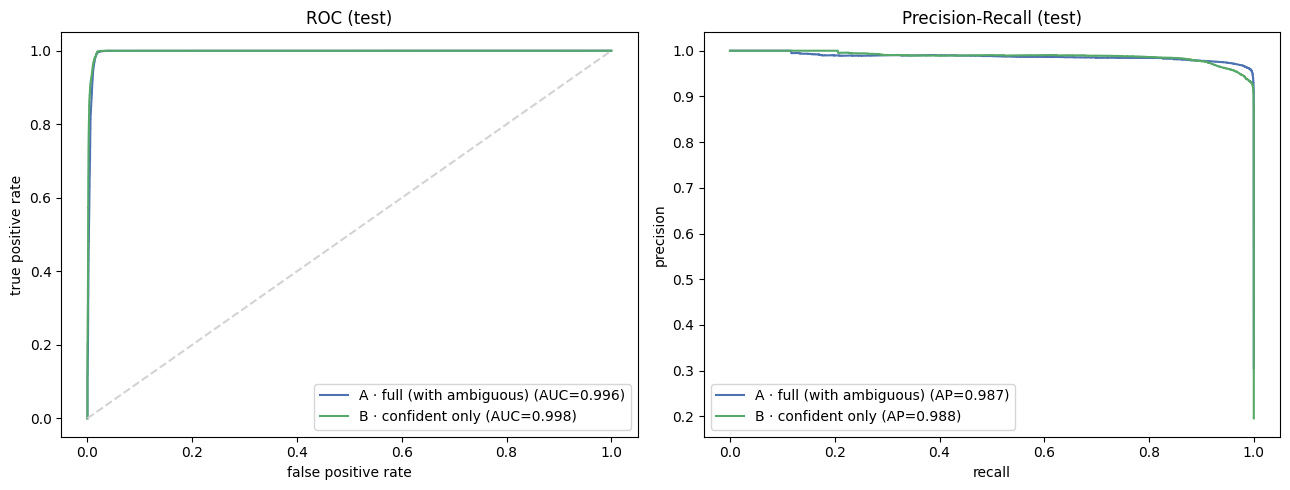

In [16]:
plot_curves([
    ('A · full (with ambiguous)', test_scored, '#4C72B0'),
    ('B · confident only',        test_conf,   '#55A868'),
])

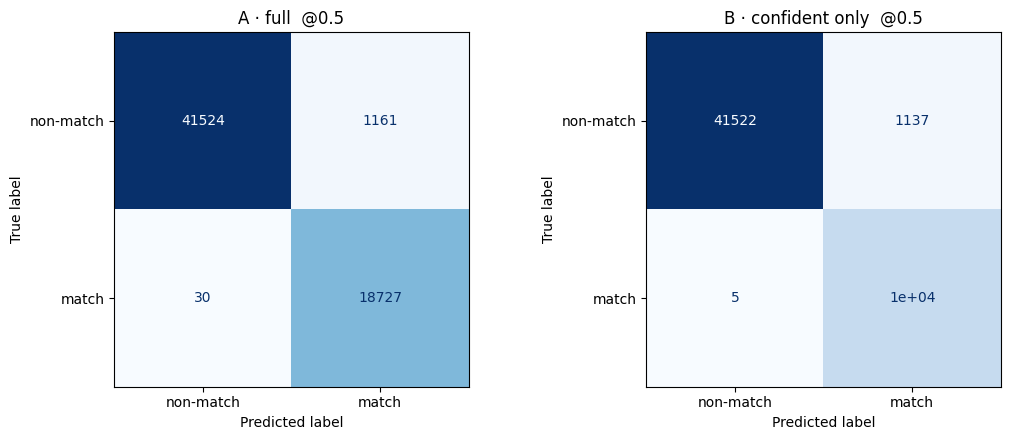

In [17]:
short = ['non-match', 'match']
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a, (name, df) in zip(ax, [('A · full', test_scored), ('B · confident only', test_conf)]):
    cm = confusion_matrix(df['is_match'], (df['match_probability'] >= 0.5).astype(int), labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=short).plot(ax=a, colorbar=False, cmap='Blues')
    a.set_title(f'{name}  @0.5')
plt.tight_layout(); plt.show()

### Predicted-probability histogram, colored by group

The requested view: where each of the three groups lands on the probability axis. A good model
pushes `confident_match` toward 1 and `confident_non_match` toward 0, with `ambiguous` smeared
across the middle — which is precisely the region a human-review threshold should capture.
(Log-count y-axis because non-matches dominate.)

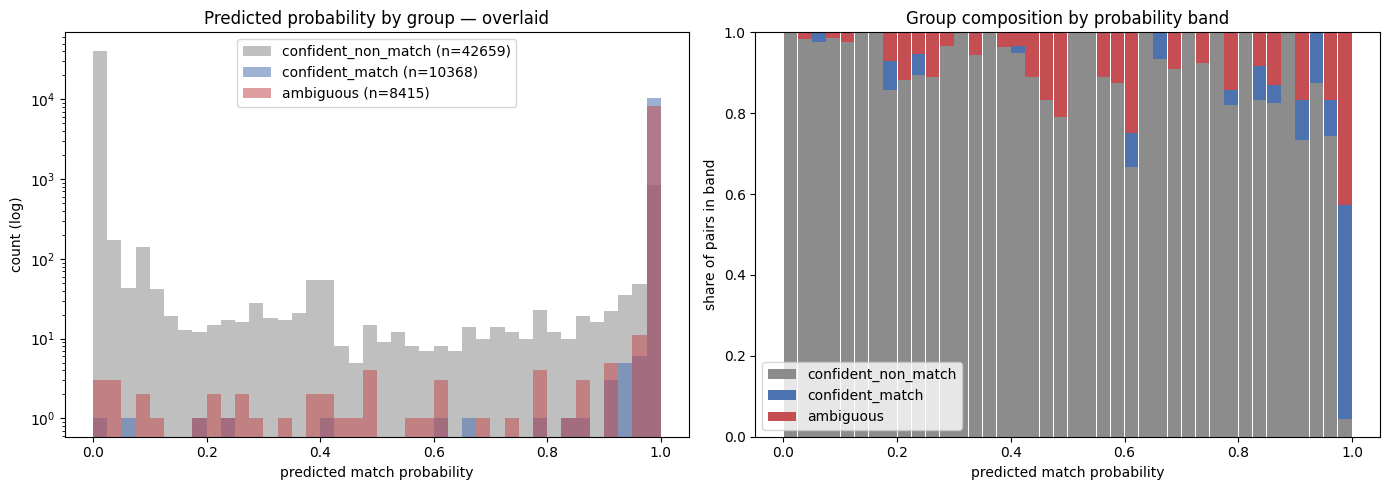

In [18]:
groups = ['confident_non_match', 'confident_match', 'ambiguous']
colors = {'confident_non_match': '#8C8C8C', 'confident_match': '#4C72B0', 'ambiguous': '#C44E52'}
bins = np.linspace(0, 1, 41)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# overlaid
for g in groups:
    sub = test_scored.loc[test_scored['pair_group'] == g, 'match_probability']
    ax[0].hist(sub, bins=bins, alpha=0.55, color=colors[g], label=f'{g} (n={len(sub)})')
ax[0].set_yscale('log')
ax[0].set(xlabel='predicted match probability', ylabel='count (log)',
          title='Predicted probability by group — overlaid')
ax[0].legend()

# stacked, normalized per bin -> composition of each probability band
counts = {g: np.histogram(test_scored.loc[test_scored['pair_group'] == g, 'match_probability'],
                          bins=bins)[0] for g in groups}
totals = np.sum([counts[g] for g in groups], axis=0)
totals[totals == 0] = 1
bottom = np.zeros(len(bins) - 1)
centers = (bins[:-1] + bins[1:]) / 2
for g in groups:
    frac = counts[g] / totals
    ax[1].bar(centers, frac, width=(bins[1] - bins[0]) * 0.95, bottom=bottom,
              color=colors[g], label=g)
    bottom += frac
ax[1].set(xlabel='predicted match probability', ylabel='share of pairs in band',
          title='Group composition by probability band')
ax[1].legend()
plt.tight_layout(); plt.show()

### Threshold sweep — picking auto-merge / review operating points

FS scores map to a review workflow: an **auto-merge** floor (high precision) and a **review** floor
below it. The table shows precision/recall on the full test set at candidate cutoffs.

In [19]:
rows = []
y = test_scored['is_match'].values
p = test_scored['match_probability'].values
for t in [0.20, 0.40, 0.50, 0.80, 0.90, 0.95, 0.99]:
    pred = (p >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y, pred, zero_division=0),
        'recall': recall_score(y, pred, zero_division=0),
        'f1': f1_score(y, pred, zero_division=0),
        'n_flagged': int(pred.sum()),
    })
pd.DataFrame(rows).round(4)

,threshold,precision,recall,f1,n_flagged
0,0.20,0.9290,0.9994,0.9629,20177
1,0.40,0.9377,0.9989,0.9673,19980
2,0.50,0.9416,0.9984,0.9692,19888
3,0.80,0.9480,0.9977,0.9722,19740
4,0.90,0.9508,0.9974,0.9735,19677
5,0.95,0.9535,0.9967,0.9747,19607
6,0.99,0.9592,0.9926,0.9757,19410


In [20]:
summary = pd.DataFrame([m_full, m_conf]).set_index('title')
print('Held-out test summary:')
summary.round(4)

Held-out test summary:


,n,roc_auc,pr_auc,precision,recall,f1
title,,,,,,
A · full test set (ambiguous included),61442,0.9962,0.9872,0.9416,0.9984,0.9692
B · confident pairs only (ambiguous excluded),53027,0.9978,0.9882,0.9011,0.9995,0.9478


## Notes / next steps (ground-truth notebook)

- **This mirrors production.** `estimate_m_from_pairwise_labels` + `u` by random sampling + the
  deterministic λ-prior is exactly the `SupervisedTraining` strategy in
  `src/models/fs_matcher/base.py`. If you want to promote a model from here, persist the trained
  linker with `linker.misc.save_model_to_json(...)` and run it through `fs-train`'s deploy-gate.
- **Compare to the EM sibling.** The gap between this notebook and `fs_splink_em_v1.ipynb` on the
  identical test set is the payoff of having gold labels.
- **Label quality drives `m`.** Because `m` comes straight from the positives, any mislabeled
  match propagates directly into the weights — worth a periodic audit of high-weight
  disagreements.
- **PATID-grouped split** for a stricter generalization estimate (see §7).
- **Scope caveat** on `u`/`λ` (§6) applies here too, though supervised `m` is far more robust to it
  than EM.